In [2]:
## import all necessary package for model training
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import joblib
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [3]:
## Extract data from - to from yahoo finance for data pre processing

start = '2000-01-01'
end = '2025-01-01'
ticker = '^GSPC'   # S&P 500 index from US Stock excahnge // yahoo finance

## Extract Data
sp500 = yf.download(ticker, start=start, end=end)

## To extract the columns from multicolumns

sp500.columns = sp500.columns.get_level_values(0)
sp500.columns.name = None

## Displaying first 10 rows
print(sp500.head(10))


/var/folders/x3/znqp056977l_nmf5cqgjdp9r0000gn/T/ipykernel_24253/3846669872.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

                  Close         High          Low         Open      Volume
Date                                                                      
2000-01-03  1455.219971  1478.000000  1438.359985  1469.250000   931800000
2000-01-04  1399.420044  1455.219971  1397.430054  1455.219971  1009000000
2000-01-05  1402.109985  1413.270020  1377.680054  1399.420044  1085500000
2000-01-06  1403.449951  1411.900024  1392.099976  1402.109985  1092300000
2000-01-07  1441.469971  1441.469971  1400.729980  1403.449951  1225200000
2000-01-10  1457.599976  1464.359985  1441.469971  1441.469971  1064800000
2000-01-11  1438.560059  1458.660034  1434.420044  1457.599976  1014000000
2000-01-12  1432.250000  1442.599976  1427.079956  1438.560059   974600000
2000-01-13  1449.680054  1454.199951  1432.250000  1432.250000  1030400000
2000-01-14  1465.150024  1473.000000  1449.680054  1449.680054  1085900000


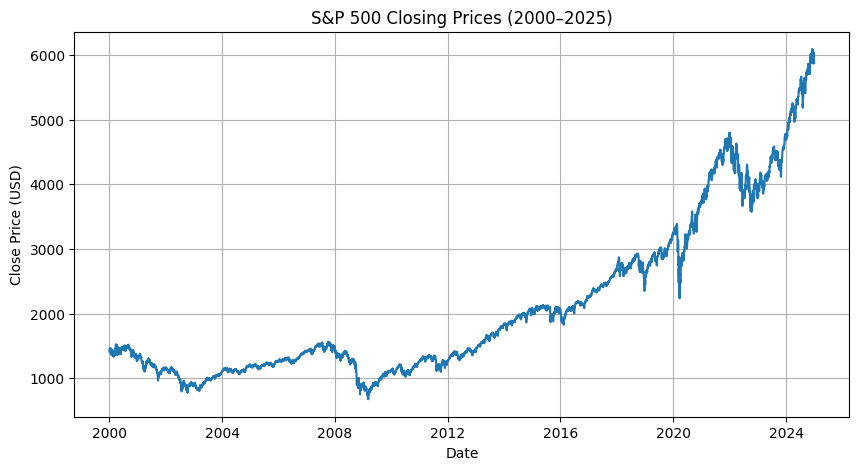

In [4]:
# Plotting the closing price of S&P500 index price
plt.figure(figsize=(10,5))
plt.plot(sp500['Close'])
plt.title('S&P 500 Closing Prices (2000–2025)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True)
plt.show()


In [5]:
## Resetting the index for data and date time pre processing
sp500.reset_index(inplace = True)

In [6]:
sp500

,Date,Close,High,Low,Open,Volume
0,2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
1,2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2,2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
3,2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
4,2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000
...,...,...,...,...,...,...
6284,2024-12-24,6040.040039,6040.100098,5981.439941,5984.629883,1757720000
6285,2024-12-26,6037.589844,6049.750000,6007.370117,6024.970215,2904530000
6286,2024-12-27,5970.839844,6006.169922,5932.950195,6006.169922,3159610000
6287,2024-12-30,5906.939941,5940.790039,5869.160156,5920.669922,3433250000


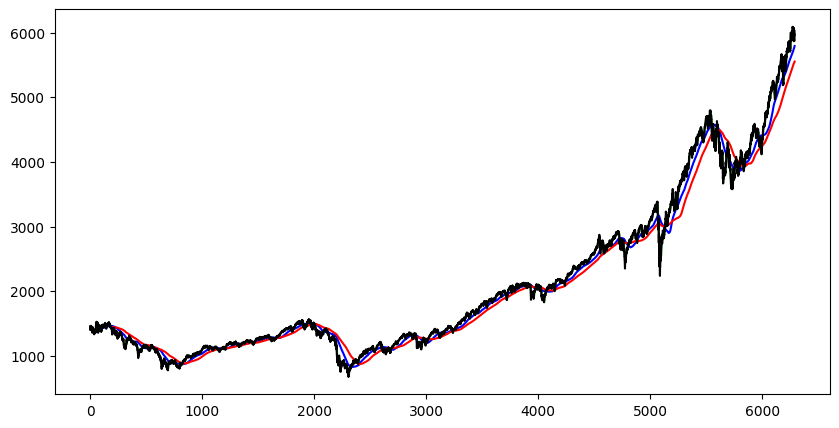

In [7]:
## Disply the stock price closing price against different moving average

moving_avg_5 = sp500['Close'].rolling(5).mean()
moving_avg_100 = sp500['Close'].rolling(100).mean()
moving_avg_200 = sp500['Close'].rolling(200).mean()

## Plot the graph
plt.figure(figsize=(10,5))
plt.plot(moving_avg_5, 'green')
plt.plot(moving_avg_100, 'blue')
plt.plot(moving_avg_200, 'red')
plt.plot(sp500['Close'], 'black')
plt.show()




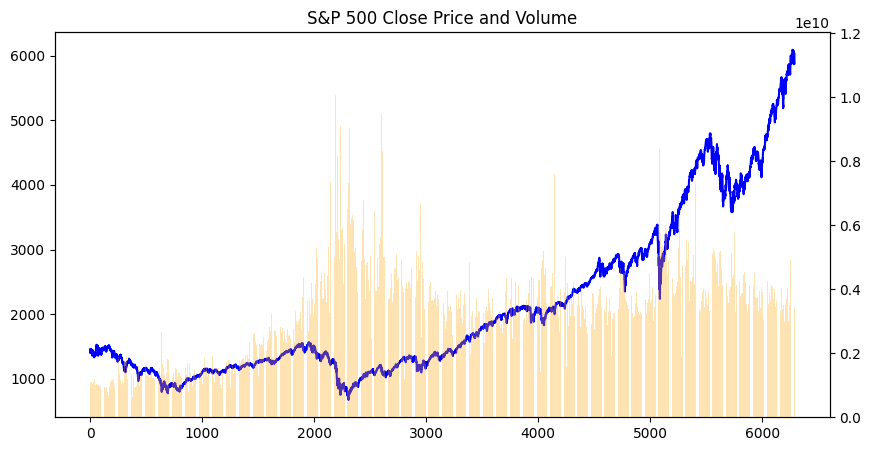

In [8]:
## Display Volume of the stock VS the price movement

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(sp500['Close'], color='blue', label='Close')
ax2 = ax1.twinx()
ax2.bar(sp500.index, sp500['Volume'], color='orange', alpha=0.3, label='Volume')
plt.title('S&P 500 Close Price and Volume')
plt.show()



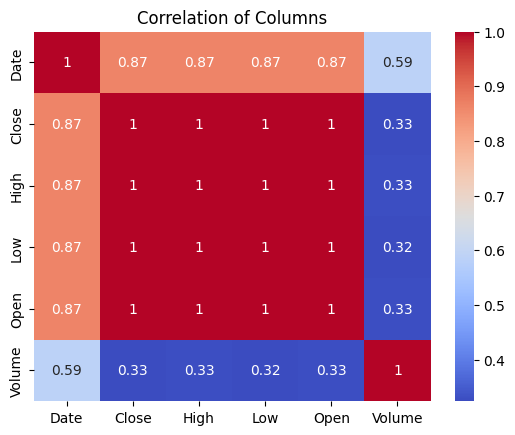

In [9]:
## Correlation Matrix
sns.heatmap(sp500.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of Columns')
plt.show()


In [10]:
## Splitting the data by time with no future data leakage to the model

total_length = len(sp500)
train_end = int(total_length * 0.8)
val_end = int(total_length * 0.9)

train_df = sp500.iloc[:train_end]
val_df   = sp500.iloc[train_end:val_end]
test_df  = sp500.iloc[val_end:]


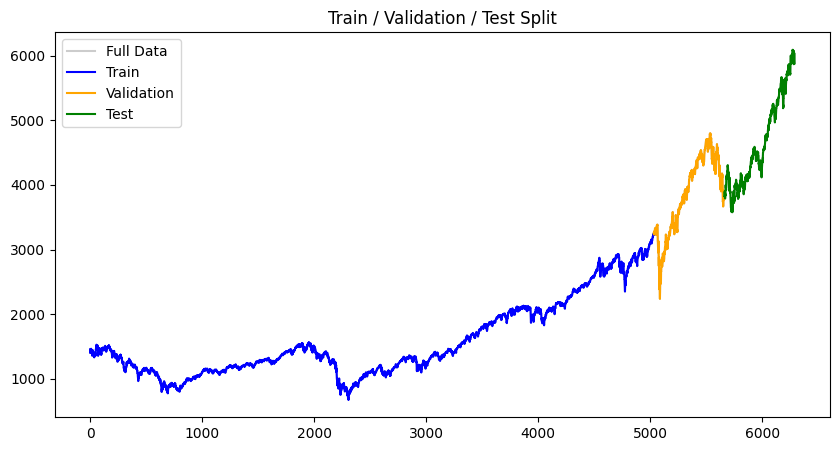

In [11]:
### Data Split // Leakage Proof

plt.figure(figsize=(10,5))
plt.plot(sp500['Close'], label='Full Data', color='gray', alpha=0.4)
plt.plot(train_df['Close'], label='Train', color='blue')
plt.plot(val_df['Close'], label='Validation', color='orange')
plt.plot(test_df['Close'], label='Test', color='green')
plt.legend()
plt.title('Train / Validation / Test Split')
plt.show()


In [12]:
## Scaling the input data

features = ['Open', 'High', 'Low', 'Close', 'Volume']
target = 'Close'

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

## MinMax Scaler fit Train and transform on Train/Val/Test
X_scaler.fit(train_df[features])
y_scaler.fit(train_df[[target]])

# Transform train/val/test
def transform(df_):
    X = X_scaler.transform(df_[features])
    y = y_scaler.transform(df_[[target]])
    return X.astype(np.float32), y.astype(np.float32)

X_train, y_train = transform(train_df)
X_val,   y_val   = transform(val_df)
X_test,  y_test  = transform(test_df)


In [13]:
## Saving the joblib for inference
os.makedirs("model", exist_ok=True)

# Saving my scaler for this project
joblib.dump(
    {'X_scaler': X_scaler, 'y_scaler': y_scaler},
    "model/stock_pred_scalers.joblib"
)

print("Scalers saved at: model/stock_pred_scalers.joblib")



Scalers saved at: model/stock_pred_scalers.joblib


In [14]:
## Implementing a sliding window of 5 days for model training

def make_sequences(X, y, window=5): ## Slidding window of 5 Days
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])     # last 5 days closing price
        ys.append(y[i+window])       # next day closing price
    return np.array(Xs), np.array(ys)


In [15]:
## Transforming with sliding window
window = 5

X_train_seq, y_train_seq = make_sequences(X_train, y_train, window)
X_val_seq,   y_val_seq   = make_sequences(X_val,   y_val,   window)
X_test_seq,  y_test_seq  = make_sequences(X_test,  y_test,  window)


In [16]:
## Data loader for batch processing

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_data = SeqDataset(X_train_seq, y_train_seq)
val_data   = SeqDataset(X_val_seq,   y_val_seq)
test_data  = SeqDataset(X_test_seq,  y_test_seq)


batch_size = 100  

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)


In [17]:
## LSTM with 3 layers

class LSTMModel(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=3, dropout=0.2):
        super(LSTMModel, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)       
        out = out[:, -1, :]         
        out = self.fc(out)
        return out

model = LSTMModel(input_size=5, hidden_size=64, num_layers=3, dropout=0.2)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



In [18]:
## Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Using device:", device)


num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train MSE: {train_loss:.6f}  |  Val MSE: {val_loss:.6f}")


Using device: cpu
Epoch [1/100]  Train MSE: 0.041941  |  Val MSE: 0.012145
Epoch [2/100]  Train MSE: 0.001497  |  Val MSE: 0.101366
Epoch [3/100]  Train MSE: 0.000810  |  Val MSE: 0.073833
Epoch [4/100]  Train MSE: 0.000672  |  Val MSE: 0.071837
Epoch [5/100]  Train MSE: 0.000574  |  Val MSE: 0.062917
Epoch [6/100]  Train MSE: 0.000511  |  Val MSE: 0.061042
Epoch [7/100]  Train MSE: 0.000490  |  Val MSE: 0.046384
Epoch [8/100]  Train MSE: 0.000444  |  Val MSE: 0.043917
Epoch [9/100]  Train MSE: 0.000404  |  Val MSE: 0.036824
Epoch [10/100]  Train MSE: 0.000401  |  Val MSE: 0.030049
Epoch [11/100]  Train MSE: 0.000351  |  Val MSE: 0.034102
Epoch [12/100]  Train MSE: 0.000326  |  Val MSE: 0.042322
Epoch [13/100]  Train MSE: 0.000330  |  Val MSE: 0.040409
Epoch [14/100]  Train MSE: 0.000301  |  Val MSE: 0.037303
Epoch [15/100]  Train MSE: 0.000300  |  Val MSE: 0.042320
Epoch [16/100]  Train MSE: 0.000287  |  Val MSE: 0.042052
Epoch [17/100]  Train MSE: 0.000278  |  Val MSE: 0.038103
Epoch

In [19]:
## Model testing
model.eval()
test_loss = 0.0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        loss = criterion(preds, yb)
        test_loss += loss.item() * xb.size(0)

test_loss /= len(test_loader.dataset)
print("Test MSE:", test_loss)


Test MSE: 0.2600876929071278


In [20]:

torch.save(model.state_dict(), "model/stock_prediction.pth")
print("Model saved at model/stacked_lstm_3layer.pth")


Model saved at model/stacked_lstm_3layer.pth


In [21]:
manual_data_low = np.array([
    [2500, 2520, 2480, 2510, 3.4e9],
    [2510, 2530, 2490, 2520, 3.2e9],
    [2520, 2540, 2500, 2530, 3.3e9],
    [2530, 2550, 2510, 2540, 3.5e9],
    [2540, 2560, 2520, 2550, 3.4e9]
])

manual_data_high = np.array([
    [5000, 5030, 4980, 5020, 3.4e9],
    [5020, 5040, 5000, 5030, 3.2e9],
    [5030, 5050, 5010, 5040, 3.5e9],
    [5040, 5060, 5020, 5050, 3.7e9],
    [5050, 5070, 5030, 5060, 3.8e9]
])

for data, label in [(manual_data_low, "LOW"), (manual_data_high, "HIGH")]:
    scaled_input = X_scaler.transform(data)
    x_tensor = torch.tensor(scaled_input, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_scaled = model(x_tensor).cpu().numpy().reshape(-1, 1)
    pred_price = y_scaler.inverse_transform(pred_scaled).ravel()[0]
    print(f"{label} data → Predicted Close: {pred_price:.2f} USD")


LOW data → Predicted Close: 2521.95 USD
HIGH data → Predicted Close: 3574.53 USD


/Users/abhishekdas/Documents/ML_FastAPI/venv_fastapi/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/abhishekdas/Documents/ML_FastAPI/venv_fastapi/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
